In [10]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df=pd.read_csv('googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [12]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
10836    False
10837    False
10838    False
10839    False
10840    False
Length: 10841, dtype: bool

In [13]:
df.isnull().sum().sort_values(ascending=False)

Rating            1474
Current Ver          8
Android Ver          3
Content Rating       1
Type                 1
Size                 0
Reviews              0
Category             0
App                  0
Price                0
Installs             0
Last Updated         0
Genres               0
dtype: int64

In [14]:
#FILL values
x=df['Rating'].median()
df.fillna({'Rating':x}, inplace=True)
x=df['Current Ver'].mode()[0]
df.fillna({'Current Ver':x}, inplace=True)
x=df['Content Rating'].mode()[0]
df.fillna({'Content Rating':x}, inplace=True)
x=df['Android Ver'].mode()[0]
df.fillna({'Android Ver':x}, inplace=True)
x=df['Type'].mode()[0]
df.fillna({'Type':x}, inplace=True)
df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 10358 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10358 non-null  str    
 1   Category        10358 non-null  str    
 2   Rating          10358 non-null  float64
 3   Reviews         10358 non-null  str    
 4   Size            10358 non-null  str    
 5   Installs        10358 non-null  str    
 6   Type            10358 non-null  str    
 7   Price           10358 non-null  str    
 8   Content Rating  10358 non-null  str    
 9   Genres          10358 non-null  str    
 10  Last Updated    10358 non-null  str    
 11  Current Ver     10358 non-null  str    
 12  Android Ver     10358 non-null  str    
dtypes: float64(1), str(12)
memory usage: 2.1 MB


In [17]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='str')

In [18]:
#Highest Rated Apps
df.sort_values('Rating', ascending=False)[['App','Rating']].head(10)

,App,Rating
10472,Life Made WI-Fi Touchscreen Photo Frame,19.0
9089,DYPSOET,5.0
7696,Foothills CP,5.0
7623,CN Resident,5.0
5506,AQ Ria Retail,5.0
5507,Accounting Quiz (AQ) Malaysia,5.0
5509,Wowkwis aq Ka'qaquj,5.0
5489,AP Art History Flashcards,5.0
10629,Florida Wildflowers,5.0
5482,meStudying: AP English Lit,5.0


In [19]:
#Most Installed Apps
df.sort_values('Installs', ascending=False)[['App','Installs']].head(10)

,App,Installs
10472,Life Made WI-Fi Touchscreen Photo Frame,Free
342,Viber Messenger,"500,000,000+"
347,imo free video calls and chat,"500,000,000+"
371,Google Duo - High Quality Video Calls,"500,000,000+"
378,UC Browser - Fast Download Private & Secure,"500,000,000+"
383,imo free video calls and chat,"500,000,000+"
385,Viber Messenger,"500,000,000+"
403,LINE: Free Calls & Messages,"500,000,000+"
420,UC Browser - Fast Download Private & Secure,"500,000,000+"
467,Viber Messenger,"500,000,000+"


In [20]:
# Best Category by Average Rating
df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

Category
1.9                    19.000000
EVENTS                  4.395313
EDUCATION               4.375385
ART_AND_DESIGN          4.355385
BOOKS_AND_REFERENCE     4.336522
PERSONALIZATION         4.327062
PARENTING               4.300000
BEAUTY                  4.283019
GAME                    4.282070
HEALTH_AND_FITNESS      4.266993
SOCIAL                  4.260714
SHOPPING                4.256250
WEATHER                 4.248780
SPORTS                  4.239031
PRODUCTIVITY            4.219410
MEDICAL                 4.212990
LIBRARIES_AND_DEMO      4.207059
AUTO_AND_VEHICLES       4.205882
FAMILY                  4.203757
PHOTOGRAPHY             4.189441
HOUSE_AND_HOME          4.185000
FOOD_AND_DRINK          4.183871
COMMUNICATION           4.175410
BUSINESS                4.175176
NEWS_AND_MAGAZINES      4.160985
COMICS                  4.160000
FINANCE                 4.148056
ENTERTAINMENT           4.136036
LIFESTYLE               4.133244
TRAVEL_AND_LOCAL        4.121941
V

In [21]:
#Top Categories by Installs
df.groupby('Category')['Installs'].sum().sort_values(ascending=False)

Category
1.9                                                                 Free
PRODUCTIVITY           500,000,000+10,000,000+100,000,000+10,000,000+...
BEAUTY                 500,000+1,000,000+100,000+500,000+1,000,000+50...
FAMILY                 50,000,000+10,000,000+100,000,000+1,000,000+5,...
WEATHER                50,000,000+1,000,000+50,000,000+10,000+10,000,...
PERSONALIZATION        50,000,000+1,000,000+100,000,000+5,000,000+100...
LIBRARIES_AND_DEMO     50,000+10,000+100,000+1,000+100,000+10,000+100...
LIFESTYLE              5,000,000+10,000,000+100,000+10,000,000+5,000,...
BOOKS_AND_REFERENCE    100,000,000+50,000+100,000+10,000,000+100,000,...
MAPS_AND_NAVIGATION    100,000,000+5,000,000+10,000,000+10,000,000+5,...
EDUCATION              100,000,000+10,000,000+100,000+5,000,000+10,00...
GAME                   100,000,000+1,000,000,000+500,000,000+10,000,0...
ENTERTAINMENT          100,000,000+1,000,000+1,000,000+10,000,000+50,...
EVENTS                 100,000+5,000,000+5

In [22]:
#Most expensive apps
df[['App','Price']].sort_values('Price', ascending=False).head()

,App,Price
10472,Life Made WI-Fi Touchscreen Photo Frame,Everyone
0,Photo Editor & Candy Camera & Grid & ScrapBook,0
1,Coloring book moana,0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",0
3,Sketch - Draw & Paint,0


In [23]:
#Total Reviews per Category
df.groupby('Category')['Reviews'].sum().sort_values(ascending=False)


Category
PARENTING              8617941763614343114133936378967107559497632484...
SOCIAL                 7815830666577313860625949173295532622492170147...
MAPS_AND_NAVIGATION    7232629156815348110480050459432695644349284201...
EDUCATION              6289924181893254485375314299776977032346407510...
COMMUNICATION          5664284769119316125257964299514290354604324341...
ENTERTAINMENT          5456208116562894829677147008910939985095241225...
SPORTS                 5211381802283662828824597951338259119951733342...
FAMILY                 4706944214544499101477412753339832026757611161...
GAME                   4447388277222642242667725425814889736920352341...
HEALTH_AND_FITNESS     4281561577380983113927233722012540059220098117...
HOUSE_AND_HOME         4179073167273861622436591324977600037711175293...
TOOLS                  3865580334935745093182392419937333127596633083...
EVENTS                 3782401137074215326089206118111555857337823230...
AUTO_AND_VEHICLES      3671598284170571295

<Axes: xlabel='Type', ylabel='count'>

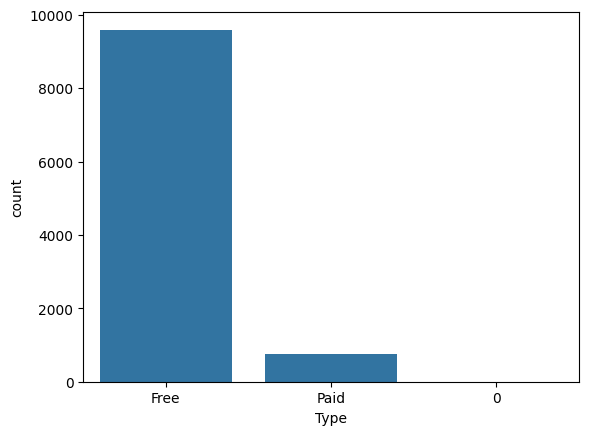

In [24]:
#Free vs Paid Apps Count
sns.countplot(x='Type', data=df)

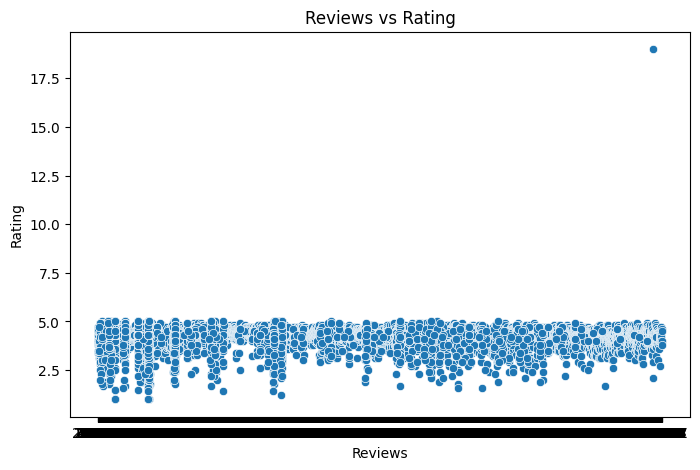

In [25]:
#Reviews vs Rating
plt.figure(figsize=(8,5))
sns.scatterplot(x='Reviews', y='Rating', data=df)

plt.title('Reviews vs Rating')
plt.show()

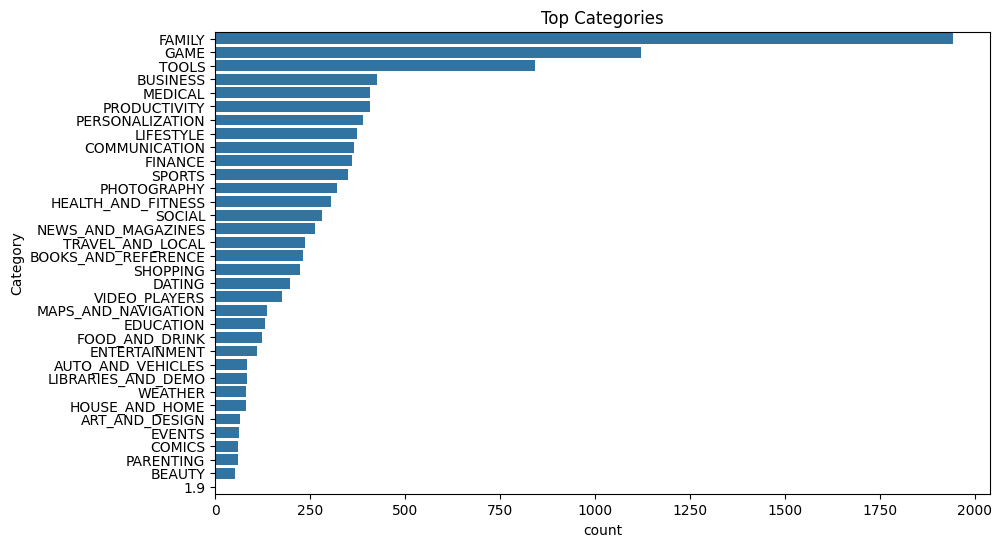

In [26]:
#Top Categories Chart
plt.figure(figsize=(10,6))
sns.countplot(y='Category', data=df,
              order=df['Category'].value_counts().index)

plt.title('Top Categories')
plt.show()

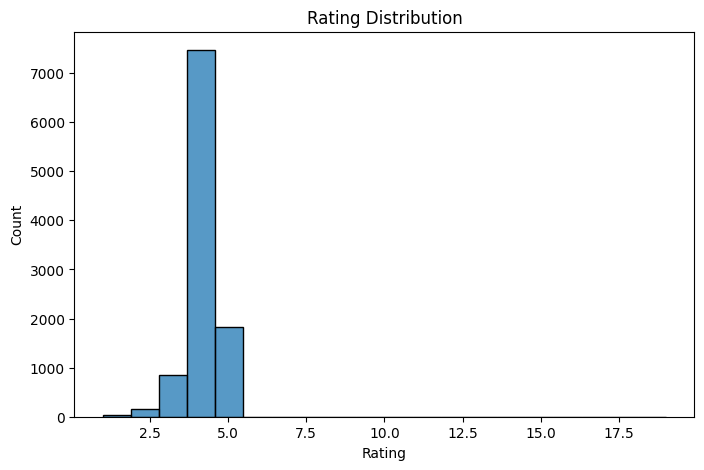

In [27]:
#Rating Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=20)

plt.title('Rating Distribution')
plt.show()

In [28]:

# Reviews
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Installs
df['Installs'] = df['Installs'].str.replace(',', '')
df['Installs'] = df['Installs'].str.replace('+', '')
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Price
df['Price'] = df['Price'].str.replace('$', '')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

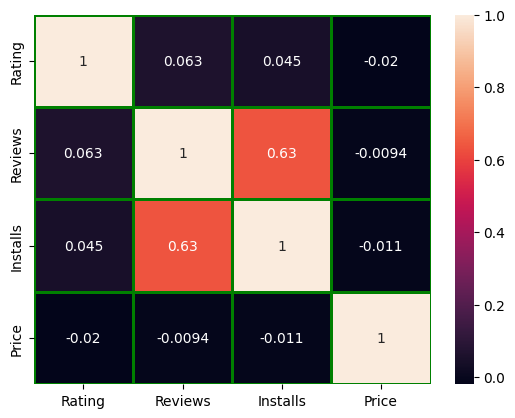

In [29]:
#Correlation Heatmap
sns.heatmap(df[['Rating','Reviews','Installs','Price']].corr(),
            annot=True,linewidth=2,linecolor='g')

plt.show()

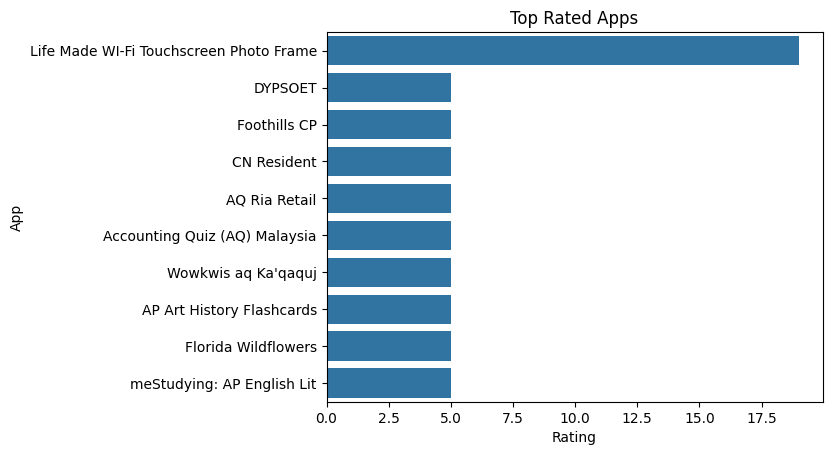

In [30]:
#Top 10 Highest Rated Apps
top_apps = df.sort_values('Rating', ascending=False).head(10)

sns.barplot(x='Rating', y='App', data=top_apps)

plt.title('Top Rated Apps')
plt.show()